# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Brandon Diego Islas Lizardi \
**Matricula:** 230550 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF4081 0%, #880E4F 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0; font-family: sans-serif;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FCE4EC; font-size: 1.1em; margin-top: 10px; font-family: sans-serif;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---|---|
|1.|[Instalaciones y Carga de Datos](#s1). | Librerias, carga del CSV, primeros comandos de estructura | 
|2.|[Diccionario de datos](#s2). | Explicacion del contenido de columnas y calcular el % de datos faltantes |
|3.|[Limpieza de datos](#s3). | Parseo de precios, valores faltantes, duplicados |
|4.|[Ingeniería de características](#s4). | Variables de texto, banderas de categoría, niveles de precio |
|5.|[Análisis univariado](#s5). | Distribuciones, valores atípicos, pruebas de normalidad |
|6.|[Análisis por categorías](#s6). | Categorías principales, precio por categoría |
|7.|[Análisis de disponibilidad](#s7). | Patrones de estado de inventario |
|8.|[Correlación y bivariado](#s8). | Mapa de calor, gráficos de dispersión |
|9.|[Pruebas de hipótesis estadísticas](#s9). | Kruskal-Wallis, Mann-Whitney U, Spearman |
|10.|[Planteamiento del problema de ML](#s10). | Matriz de características, train/test split |
|11.|[Marco de selección de modelos](#s11). | Tabla comparativa de modelos, métricas |
|12.|[Modelos de regresión](#s12). | Entrenamiento y evaluación de 5 modelos |
|13.|[Ajuste de hiperparámetros](#s13). | GridSearchCV sobre Random Forest |
|14.|[Comparación de modelos](#s14). | Resultados lado a lado, importancia de variables |
|15.|[Conclusiones e informe de negocio](#s15). | Hallazgos y recomendaciones |

**Conclusion**

El presente análisis exploratorio de datos (EDA) sobre un conjunto de datos de productos de Amazon permitió comprender en profundidad la estructura, calidad y comportamiento de la información disponible. A lo largo del proceso se identificaron valores faltantes, posibles registros duplicados y patrones relevantes relacionados con precios, categorías y disponibilidad de productos.

Mediante técnicas de limpieza de datos, visualización estadística e ingeniería de características, se logró preparar un conjunto de datos más consistente y adecuado para la construcción de modelos predictivos. Asimismo, el análisis descriptivo y las pruebas estadísticas facilitaron la identificación de relaciones significativas entre variables, aportando información valiosa para la toma de decisiones.

Finalmente, la implementación y comparación de modelos de aprendizaje automático permitió evaluar distintas alternativas para la predicción de variables de interés, demostrando la importancia de una adecuada preparación y exploración de los datos antes de aplicar técnicas de Machine Learning. En conjunto, este proyecto evidencia cómo Python y sus bibliotecas de análisis de datos constituyen herramientas fundamentales para transformar datos en conocimiento útil y accionable.



## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [2]:
# ============================================================
# SECCIÓN 1 — Configuración y carga de datos
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ ¡Todas las librerías cargaron correctamente!')


✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ XGBoost : False
✅ ¡Todas las librerías cargaron correctamente!


In [3]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print (f' shape   : {df_raw.shape}')
print (f' Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

 shape   : (1446, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame. <a id='s2'></a>

In [4]:
# Column dictionary
col_info = {
    'rl'             : 'URL del Producto en Amazon.in',
    'asin'            : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'            : 'Nombre o Título del Producto',
    'overview'        : 'Breve Reseña del Prodcuto (mayoría vacío [])',
    'price'           : 'Precio como string (e.g. "1,600.00")',
    'currency'        : 'Código de Divisa (todas en INR)',
    'availability'    : 'Texto del Status del Stock (Inventario)',
    'brand'           : 'Nombre de la Marca/Autor ',
    'about_item'      : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'      : 'URLs de Imágenes del Producto',
    'description'     : 'Descripción detalla y completa (mayoría faltante)',
    'specifications'  : 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'      : 'Subcategoría de nivel 1',
    'category_2'      : 'Subcategoría de nivel 2',
    'category_3'      : 'Subcategoría de nivel 3',
    'breadcrumbs'     : 'Ruta de Categorías'
}

print('Diccionario por columnas:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s} |'
        f'{desc[:45]:45s} |'
        f'Missing: {missing_pct:.0f}%'
    )

Diccionario por columnas:
rl                   |URL del Producto en Amazon.in                 |Missing: 0%
asin                 |Número Estandarizado de Identificación por Am |Missing: 0%
name                 |Nombre o Título del Producto                  |Missing: 0%
overview             |Breve Reseña del Prodcuto (mayoría vacío [])  |Missing: 0%
price                |Precio como string (e.g. "1,600.00")          |Missing: 24%
currency             |Código de Divisa (todas en INR)               |Missing: 24%
availability         |Texto del Status del Stock (Inventario)       |Missing: 34%
brand                |Nombre de la Marca/Autor                      |Missing: 1%
about_item           |Detalles/Especificaciones (mayoría faltante)  |Missing: 91%
img_source           |URLs de Imágenes del Producto                 |Missing: 1%
description          |Descripción detalla y completa (mayoría falta |Missing: 92%
specifications       |Especificaciones Técnicas                     |Missing: 

## 3. Limpieza de datos <a id='s3'></a>

<div style="background:#e6f2ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#003366;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECCIÓN 3 — Limpieza de datos
# ============================================================
df = df_raw.copy()

# ---------------------------------------------------------------------
# —- Parse price —-
# ---------------------------------------------------------------------
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)


# ---------------------------------------------------------------------
# —- Standardise availability —-
# ---------------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:               return 'In Stock'
    if 'unavailable' in a:           return 'Unavailable'
    if '1 to 3' in a:                 return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:   return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)


# ---------------------------------------------------------------------
# —- Text length features —-
# ---------------------------------------------------------------------

df['name_length'] = df['name'].fillna('').str.len()
df['name_words']  = df['name'].fillna('').str.split().str.len()
df['has_brand']   = df['brand'].notna().astype(int)
df['has_desc']    = df['description'].notna().astype(int)
df['has_specs']   = df['specifications'].notna().astype(int)


# ---------------------------------------------------------------------
# —- Duplicate check —-
# ---------------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

# Mostrar las primeras 5 filas con columnas seleccionadas
df[['name', 'price_clean', 'avail_clean', 'primary_category', 'name_length']].head(5)

✅ Price parsed: 1,094 / 1,446 products
✅ Duplicate ASINs: 5
✅ Availability categories: {'In Stock': 607, 'Unknown': 486, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


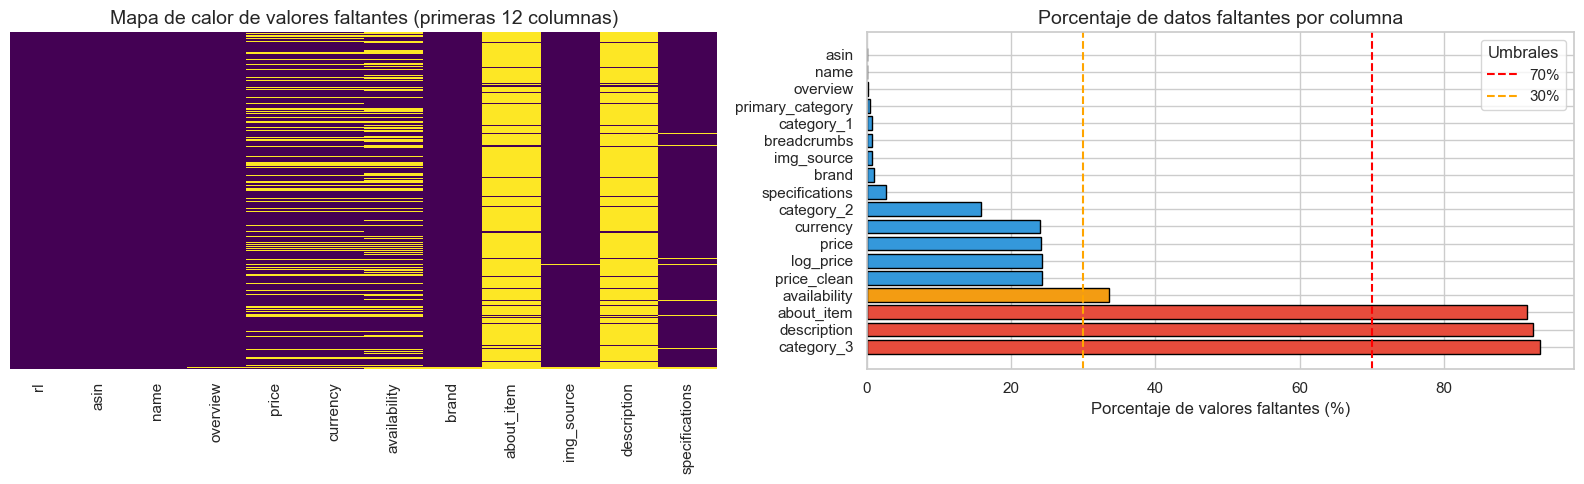

                  Missing Count  Missing Pct
category_3                 1349         93.3
description                1334         92.3
about_item                 1323         91.5
availability                486         33.6
price_clean                 352         24.3
log_price                   352         24.3
price                       350         24.2
currency                    347         24.0
category_2                  229         15.8
specifications               39          2.7
brand                        14          1.0
img_source                   11          0.8
breadcrumbs                  11          0.8
category_1                   10          0.7
primary_category              7          0.5
overview                      3          0.2
name                          2          0.1
asin                          2          0.1


In [34]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)
axes[0].set_title('Mapa de calor de valores faltantes (primeras 12 columnas)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = [
    '#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
    for v in mv['Missing Pct']
]

axes[1].barh(mv.index, mv['Missing Pct'],
             color=colors_mv, edgecolor='black')

axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')

axes[1].set_xlabel('Porcentaje de valores faltantes (%)')
axes[1].set_title('Porcentaje de datos faltantes por columna')
axes[1].legend(title='Umbrales')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de caracteristicas (Feature Engineering) <a id='s4'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antiguedad y 
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [7]:
# ============================================================
# SECCIÓN 4 — Ingeniería de características
# ============================================================

# ── Banderas de categoría ────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Banderas de subcategoría ─────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Banderas de disponibilidad ──────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Variables de precio ──────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Codificar etiqueta de la categoría principal ────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de características generadas: {len(df.columns)}')
print('\nDistribución de niveles de precio:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total de características generadas: 39

Distribución de niveles de precio:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    260
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariante <a id='s5'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Las gráficas que generamos nos ayudan a visualizar el inventario de los productos de mi dataset y a mostrar qué grupos tienen el mayor volumen de datos. También nos muestran la disponibilidad de los artículos; en palabras simples,<b
nos dicen si hay stock o si se trata de un producto agotado.
    </div>

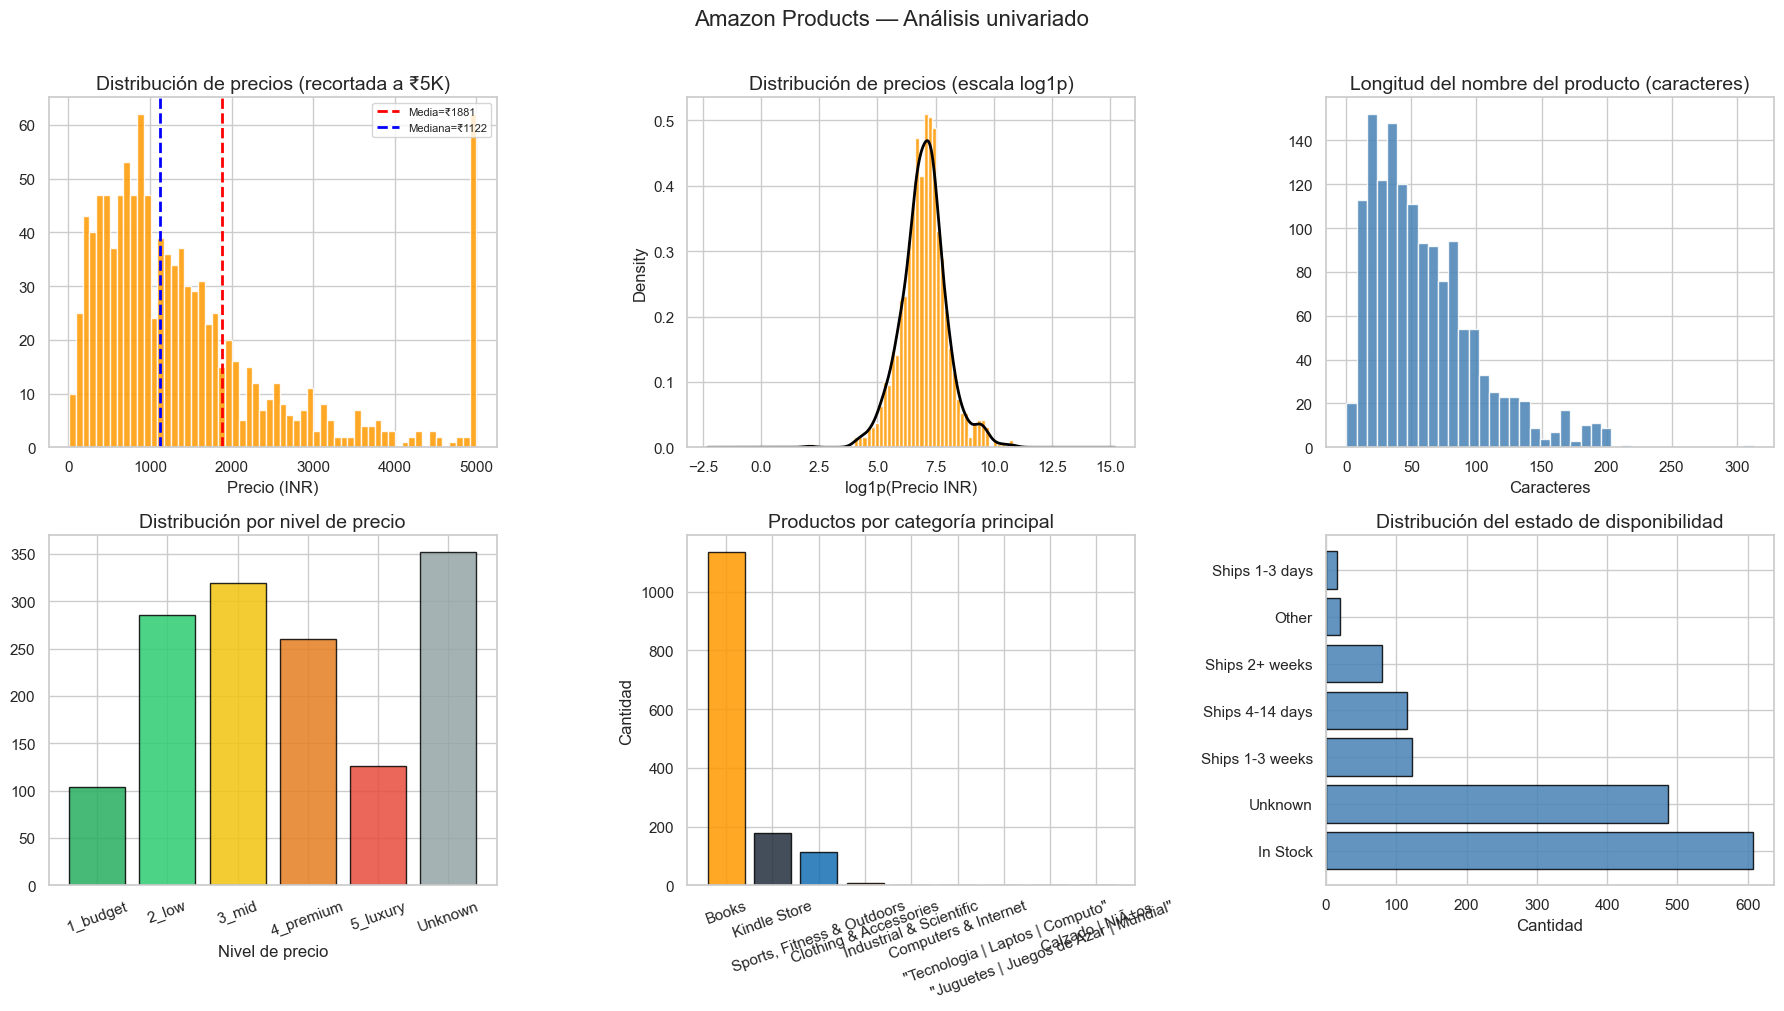

Prueba de Shapiro-Wilk (precio log, n=500): stat=0.9823, p=0.000009
El precio está aún no es normal después de la transformación logarítmica

Estadísticas del precio (INR):
count     1087.00
mean      1881.16
std       3339.62
min          7.00
25%        612.53
50%       1122.00
75%       1850.00
max      50555.00


In [8]:
# ============================================================
# SECCIÓN 5 — Análisis univariado
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Precio bruto
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de precios (recortada a ₹5K)')
axes[0,0].set_xlabel('Precio (INR)'); axes[0,0].legend(fontsize=8)

# Precio logarítmico
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# Longitud del nombre
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del nombre del producto (caracteres)')
axes[0,2].set_xlabel('Caracteres')

# Nivel de precio
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por nivel de precio')
axes[1,0].set_xlabel('Nivel de precio'); axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por categoría principal')
axes[1,1].set_ylabel('Cantidad'); axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del estado de disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle('Amazon Products — Análisis univariado', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Prueba de normalidad
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Prueba de Shapiro-Wilk (precio log, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'El precio está {"normalmente distribuido después de la transformación logarítmica" if p > 0.05 else "aún no es normal después de la transformación logarítmica"}')
print(f'\nEstadísticas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

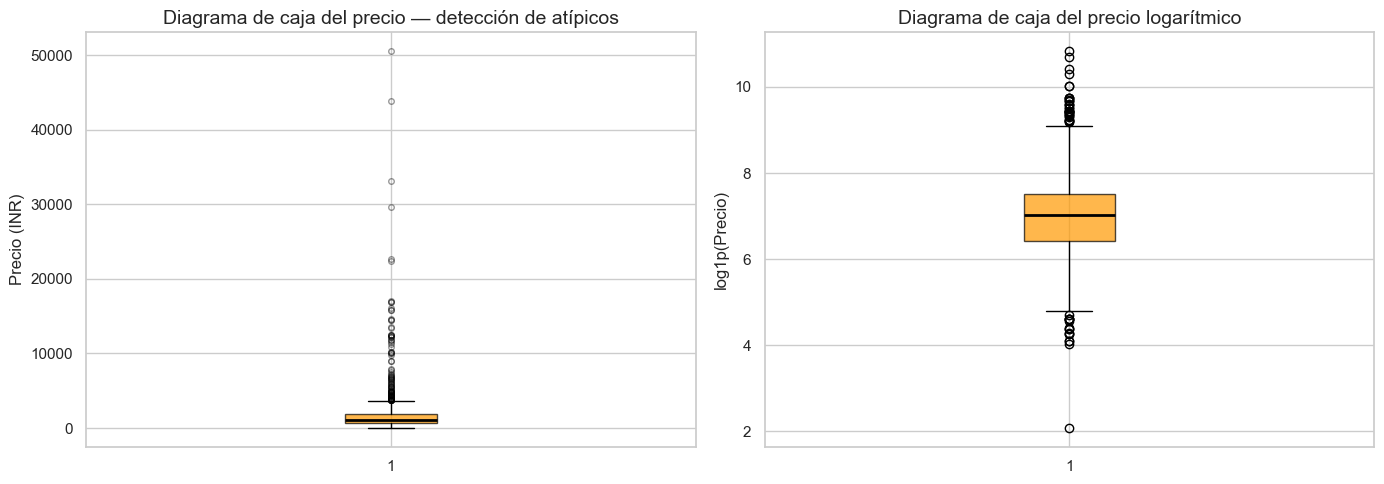

Valores atípicos por IQR: 93 (8.6%)
Rango de precio (sin atípicos): ₹-1244 – ₹3706

Top 10 productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00           

In [9]:
# Análisis de valores atípicos — diagrama de caja e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Diagrama de caja del precio — detección de atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Diagrama de caja del precio logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'Valores atípicos por IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precio (sin atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 productos más caros:')
print(df_priced.nlargest(10, "price_clean")[["name","price_clean","primary_category"]].to_string(index=False))


## 6.Análisis de Categorías <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Este análisis nos sirve para ver cuáles pasillos de la tienda acumulan más mercancía y cuáles manejan los precios más altos. Al revisar el volumen de artículos y cruzarlo con sus costos, podemos descubrir en qué partes del negocio se concentra el dinero real. Técnicamente, esto nos permite evaluar cómo se relacionan las variables de tipo texto (las categorías) con los valores numéricos (los precios), ayudándonos a identificar la concentración de los datos y el valor total acumulado antes de entrenar cualquier modelo de predicción. <b>
    </div>

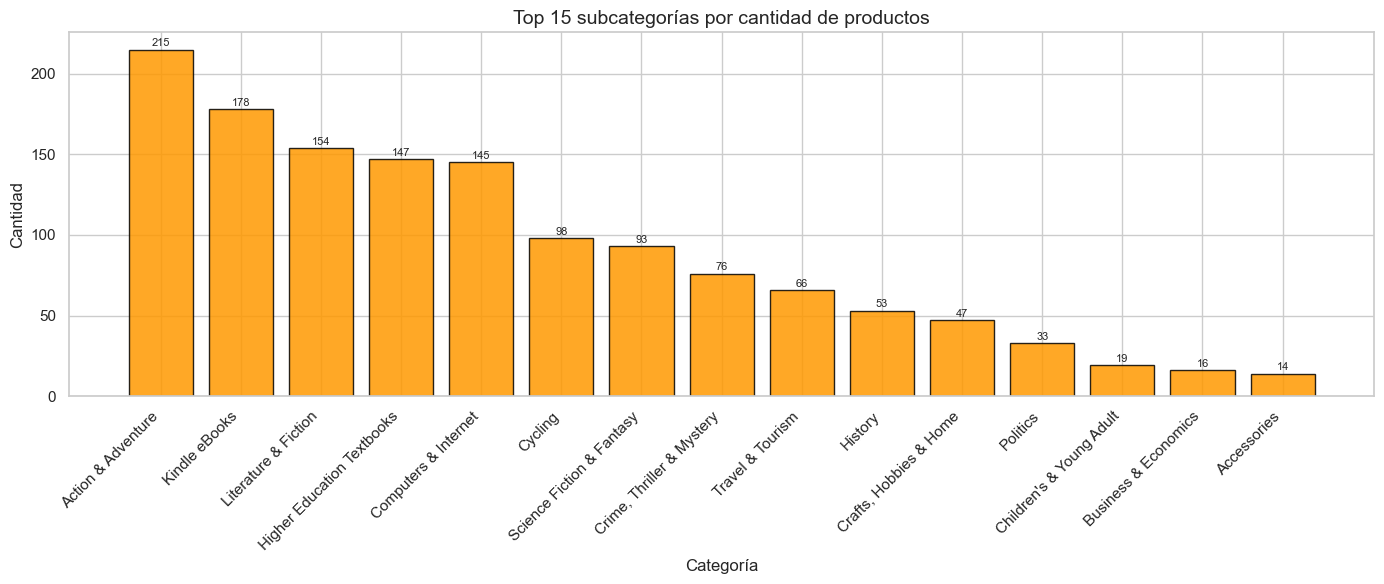

In [10]:
# ============================================================
# SECCIÓN 5 — Análisis por categorías
# ============================================================
# Top 15 subcategorías por cantidad
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 subcategorías por cantidad de productos')
plt.xlabel('Categoría'); plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


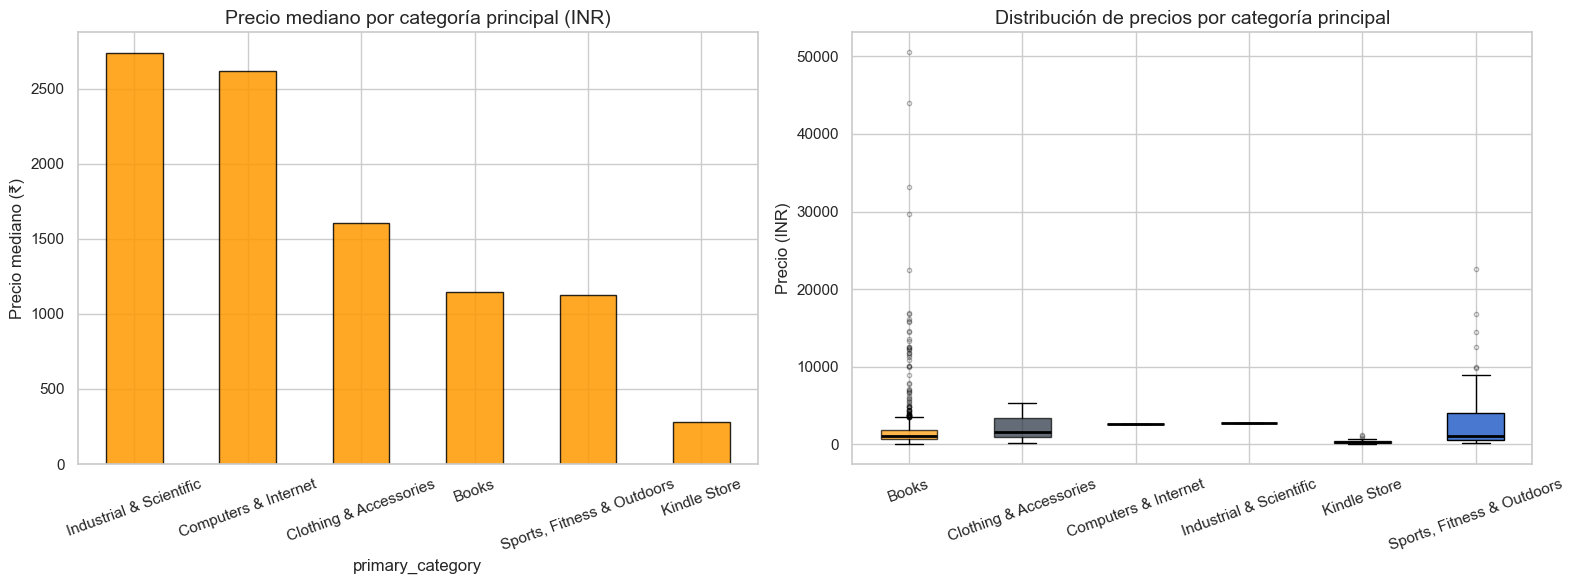

Estadísticas de precio por categoría principal:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Computers & Internet        2615.0  2615.0      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [11]:
# Precio por categoría principal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Precio mediano por categoría principal (INR)')
axes[0].set_ylabel('Precio mediano (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Diagrama de caja
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_xticklabels(cat_price.index)
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Distribución de precios por categoría principal')
axes[1].set_ylabel('Precio (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Estadísticas de precio por categoría principal:')
print(cat_price.to_string())

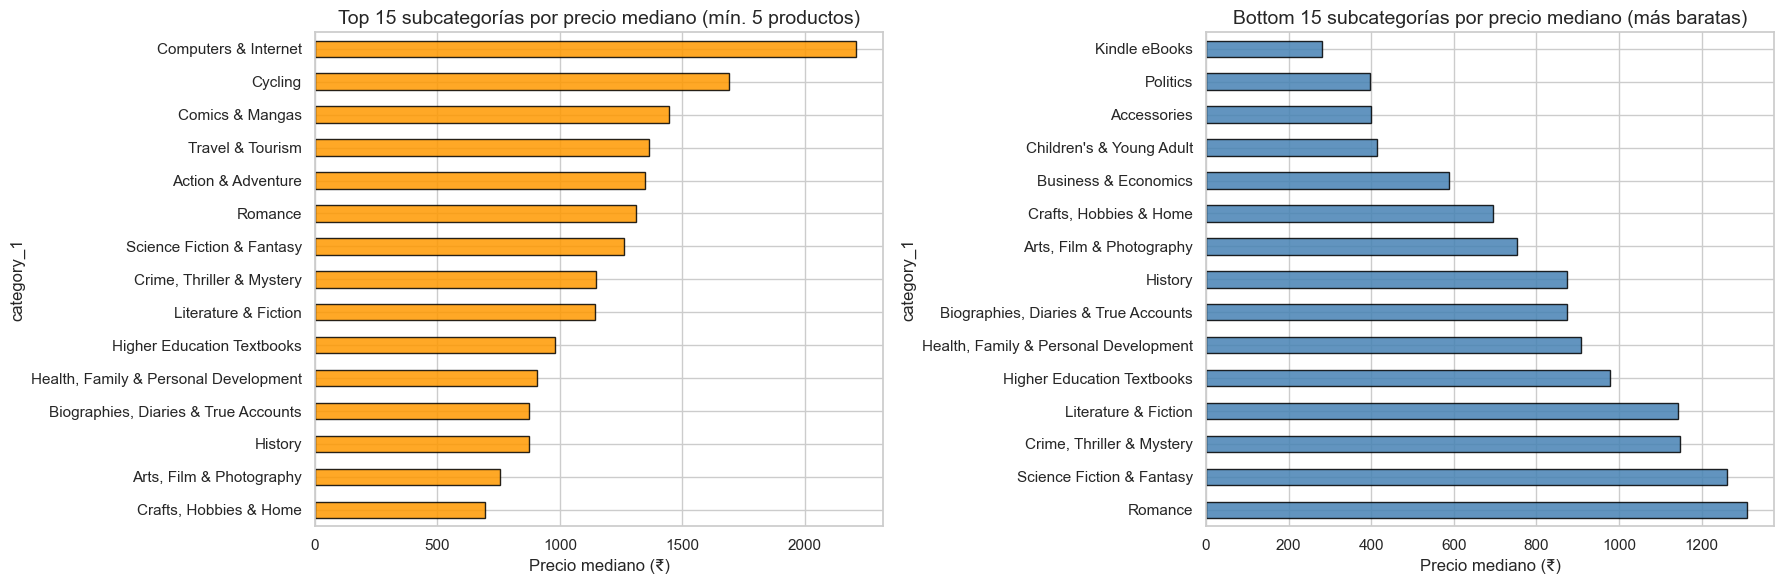

In [12]:
# Top 15 subcategorías por precio mediano
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 subcategorías por precio mediano (mín. 5 productos)')
axes[0].set_xlabel('Precio mediano (₹)')

# Bottom 15 (más baratas)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 subcategorías por precio mediano (más baratas)')
axes[1].set_xlabel('Precio mediano (₹)')

plt.tight_layout(); plt.show()


## 7.Análisis de Disponibilidad <a id='s7'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>
Este análisis sirve para entender cómo se distribuye el inventario de los productos y
si el hecho de que un artículo esté agotado o disponible tiene alguna relación con su costo. Al cruzar los precios con el estado del stock,
podemos descubrir de forma sencilla si los productos más caros o exclusivos tienden a acabarse más rápido que los normales. Técnicamente, este 
bloque nos permite evaluar una variable categórica discreta mediante proporciones (porcentajes) y formas visuales, ayudándonos a comprobar si existe
patrones importantes en el comportamiento de la tienda antes de pasar a la etapa de predicción con los modelos.<b>
<div>

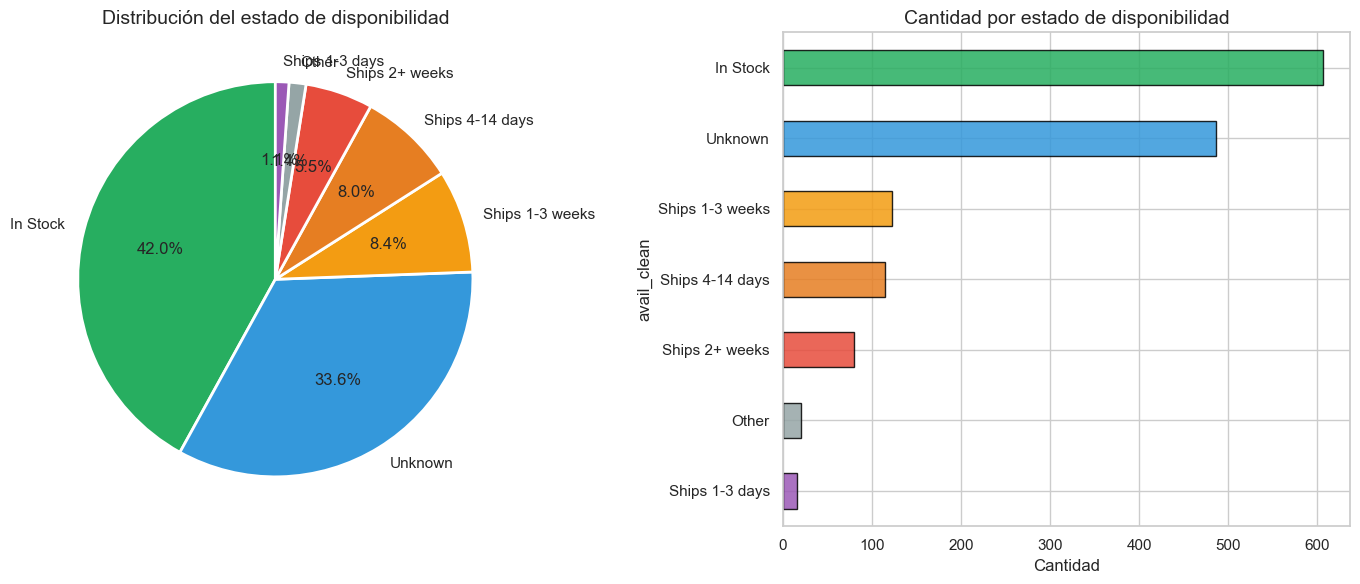

In [13]:
# ============================================================
# SECCIÓN 6 — Análisis de disponibilidad
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del estado de disponibilidad')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Cantidad por estado de disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout(); plt.show()


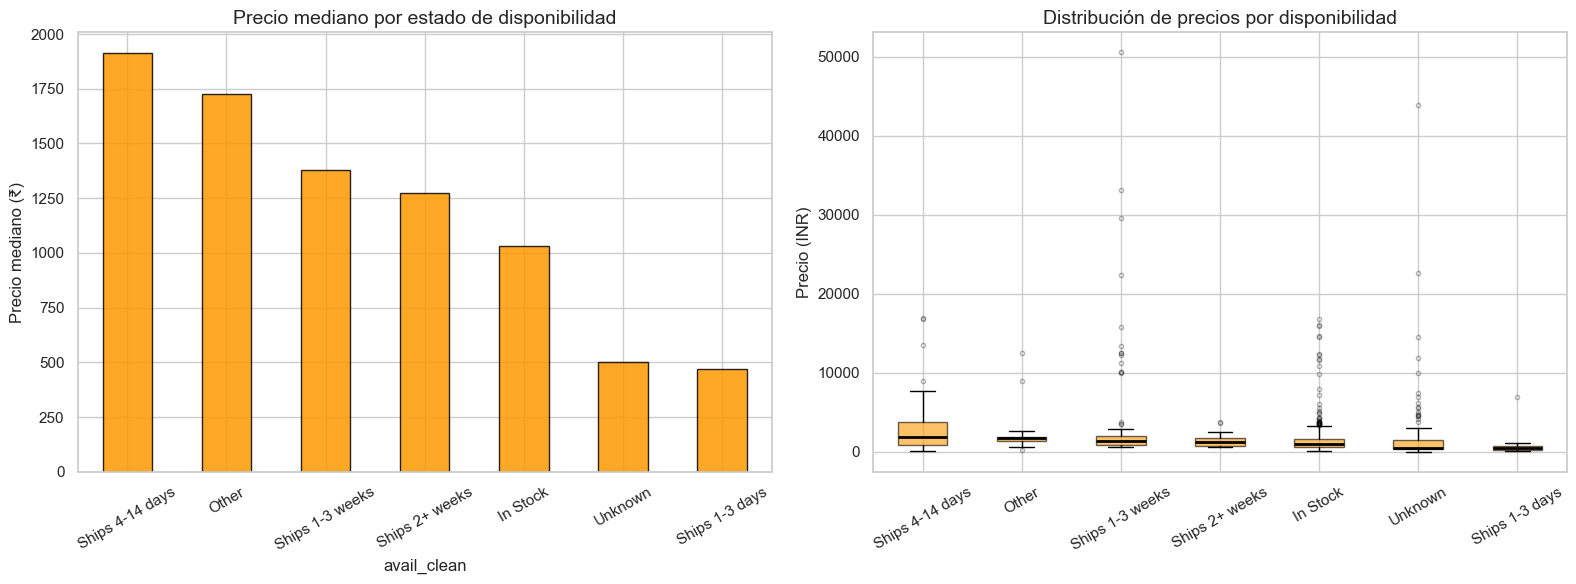

Precio por disponibilidad:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.5  3226.6    122
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [14]:
# Precio por estado de disponibilidad
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Precio mediano por estado de disponibilidad')
axes[0].set_ylabel('Precio mediano (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_xticklabels(avail_price.index)
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Distribución de precios por disponibilidad')
axes[1].set_ylabel('Precio (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Precio por disponibilidad:')
print(avail_price.to_string())

## 8. Correlación y análisis bivariado  <a id='s8'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué variables se correlacionan más con el precio? ¿La longitud del nombre predice el precio?
</div>

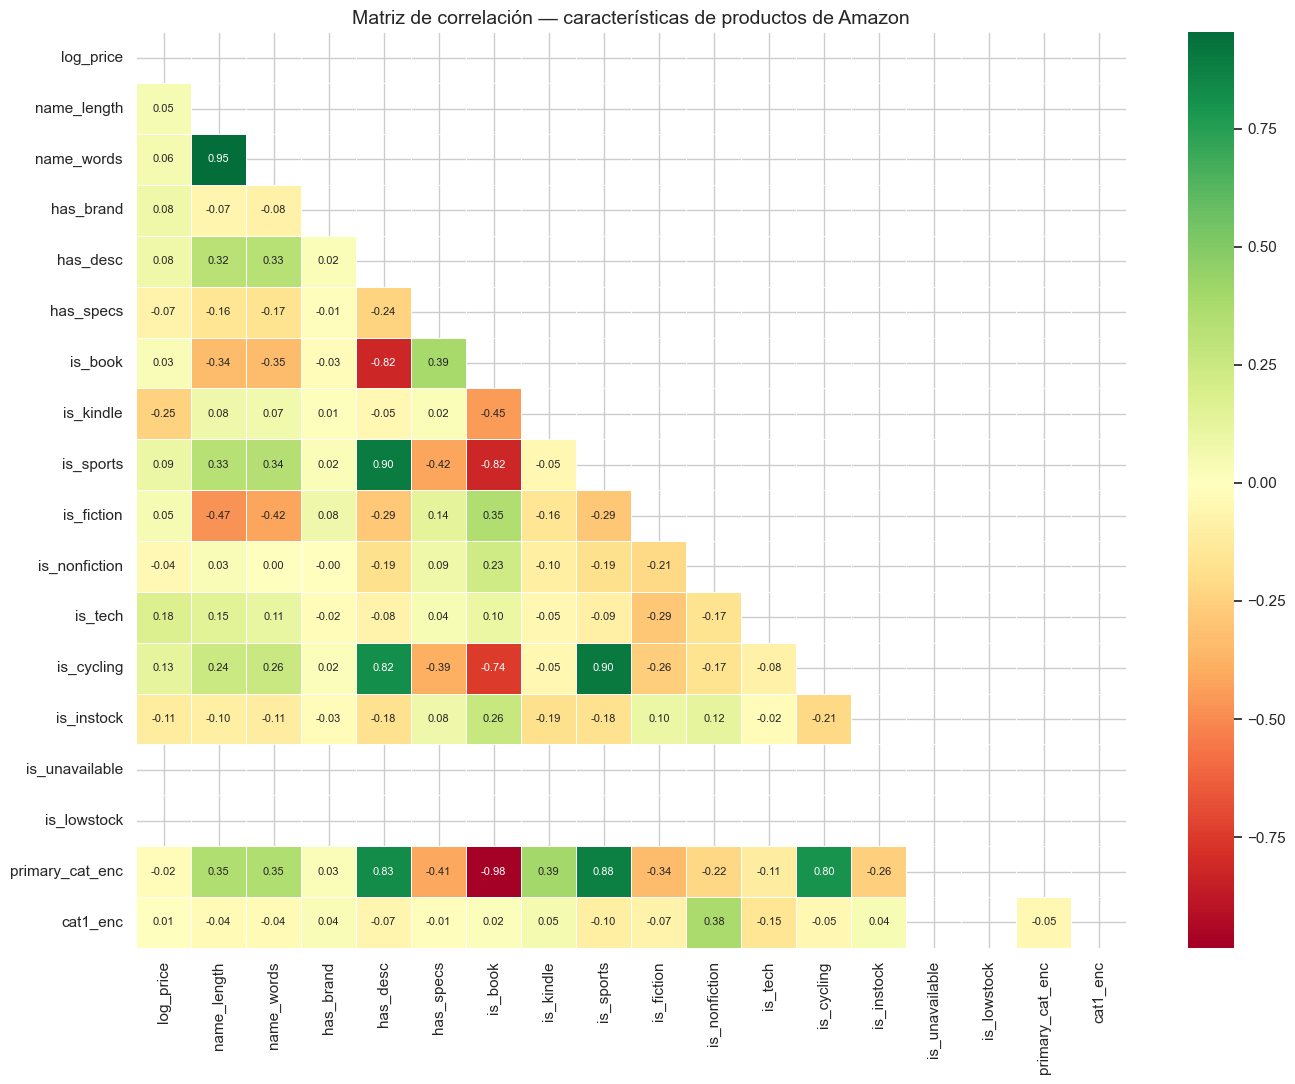

Principales correlaciones con log_price:
is_tech            0.178700
is_cycling         0.126665
is_sports          0.091764
has_brand          0.083788
has_desc           0.083304
name_words         0.055104
is_fiction         0.052686
name_length        0.049775
is_book            0.034124
cat1_enc           0.006765
primary_cat_enc   -0.019787
is_nonfiction     -0.044517
has_specs         -0.074902
is_instock        -0.114018
is_kindle         -0.246647
is_unavailable          NaN
is_lowstock             NaN


In [16]:
# ============================================================
# SECCIÓN 7 — Análisis de correlación
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de correlación — características de productos de Amazon', fontsize=14)
plt.tight_layout(); plt.show()

print('Principales correlaciones con log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

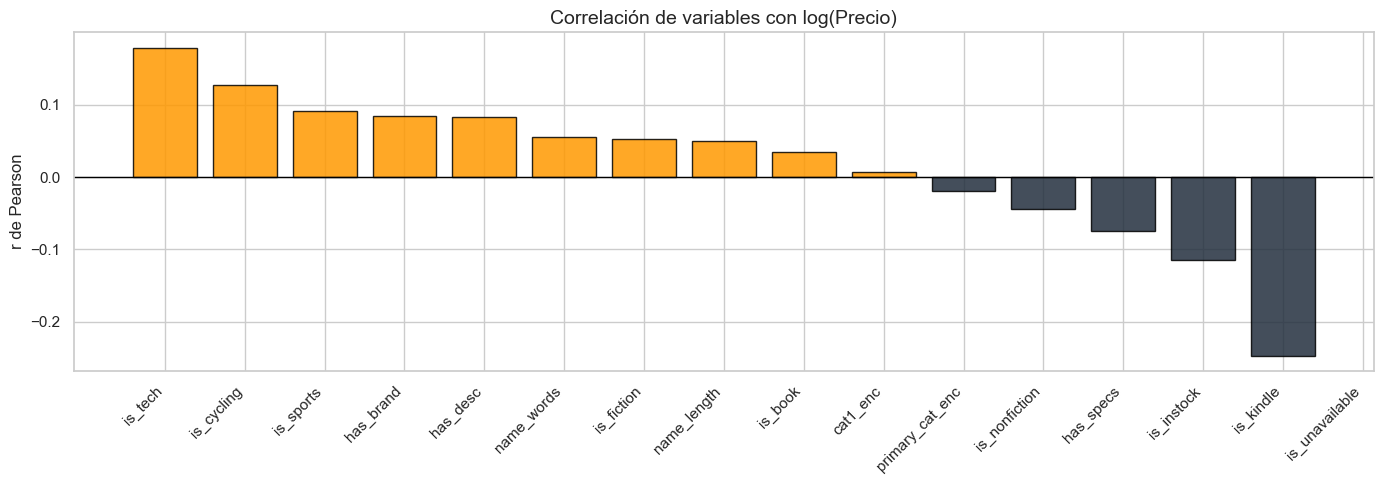

In [18]:
# Gráfico de barras de correlación de variables
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Correlación de variables con log(Precio)')
plt.ylabel('r de Pearson'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


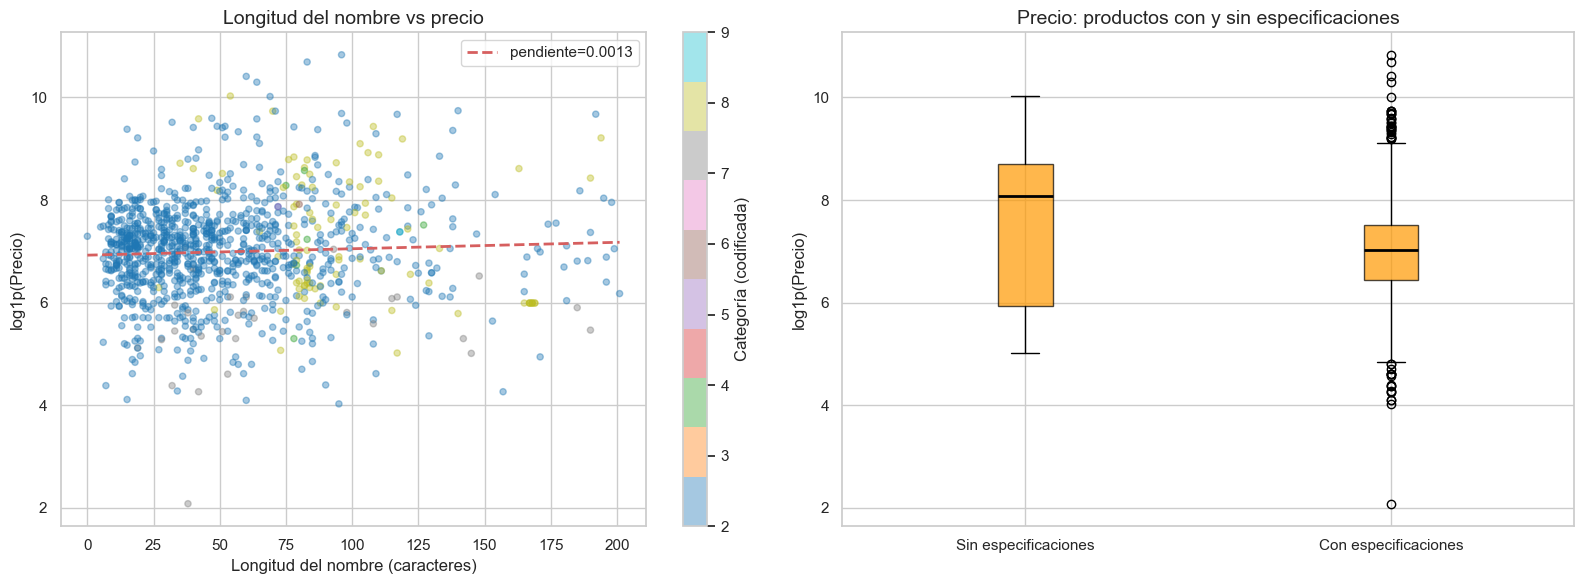

In [19]:
# Dispersión: longitud del nombre vs precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')
axes[0].set_xlabel('Longitud del nombre (caracteres)'); axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del nombre vs precio'); axes[0].legend()

# Precio según tiene especificaciones
bp = axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                    patch_artist=True,
                    boxprops=dict(facecolor='#FF9900', alpha=0.7),
                    medianprops=dict(color='black', lw=2))
axes[1].set_title('Precio: productos con y sin especificaciones')
axes[1].set_ylabel('log1p(Precio)')
# establecer etiquetas manualmente (evita el parámetro `labels` que provoca error en algunas versiones)
axes[1].set_xticklabels(['Sin especificaciones', 'Con especificaciones'])

plt.tight_layout(); plt.show()


## 9. Pruebas de hipótesis estadísticas  <a id='s9'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color: #0066cc;">
Usamos <b>pruebas no paramétricas</b> (Kruskal-Wallis, Mann-Whitney U) porque el precio está fuertemente sesgado y no sigue una distribución normal. α = 0.05.
</div>

| # | Hipótesis | Prueba |
|---|---|---|
| H1 | El precio difiere significativamente entre categorías principales | Kruskal-Wallis |
| H2 | El precio de Books es significativamente menor que el de Sports | Mann-Whitney U |
| H3 | Los productos en stock tienen precios diferentes a los no disponibles | Mann-Whitney U |
| H4 | La longitud del nombre se correlaciona positivamente con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen precios más altos | Mann-Whitney U |


In [20]:
# ============================================================
# SECCIÓN 8 — Pruebas de hipótesis
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, mediana=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, mediana=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULTADO: {"✅ RECHAZAR H0 — Diferencia significativa." if p < alpha else "❌ NO se rechaza H0."}')
    print()
    return p

# H1: precio entre categorías principales — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print('H1: Precio entre categorías principales — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — El precio difiere entre categorías." if p1 < alpha else "❌ NO se rechaza H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Precio de Books vs Sports',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Books', 'Sports')

# H3: En stock vs no disponible
p3 = mw_test('H3: Precio en stock vs no disponible',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'En stock', 'No disponible')

# H4: longitud del nombre vs precio — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print('H4: Longitud del nombre vs precio — Correlación de Spearman')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — Correlación significativa." if p4 < alpha else "❌ NO se rechaza H0."}')
print()

# H5: con especificaciones vs sin especificaciones
p5 = mw_test('H5: Productos con vs sin especificaciones',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Con especificaciones', 'Sin especificaciones')

H1: Precio entre categorías principales — Kruskal-Wallis
  Books                              : n=955, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  H=55.8663, p=0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Books vs Sports
  Books: n=955, mediana=₹1145
  Sports: n=93, mediana=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULTADO: ❌ NO se rechaza H0.

H3: Precio en stock vs no disponible
  En stock: n=599, mediana=₹1030
  No disponible: n=0, mediana=₹nan
  Mann-Whitney U=nan, p=nan
  RESULTADO: ❌ NO se rechaza H0.

H4: Longitud del nombre vs precio — Correlación de Spearman
  rho=0.0351, p=0.247712
  RESULTADO: ❌ NO se rechaza H0.

H5: Productos con vs sin especificaciones
  Con especificaciones: n=1065, mediana=₹1117
  Sin especificaciones: n=22, mediana=₹3278
  Mann-Whitney U=9290, p=0.096151
  RESUL

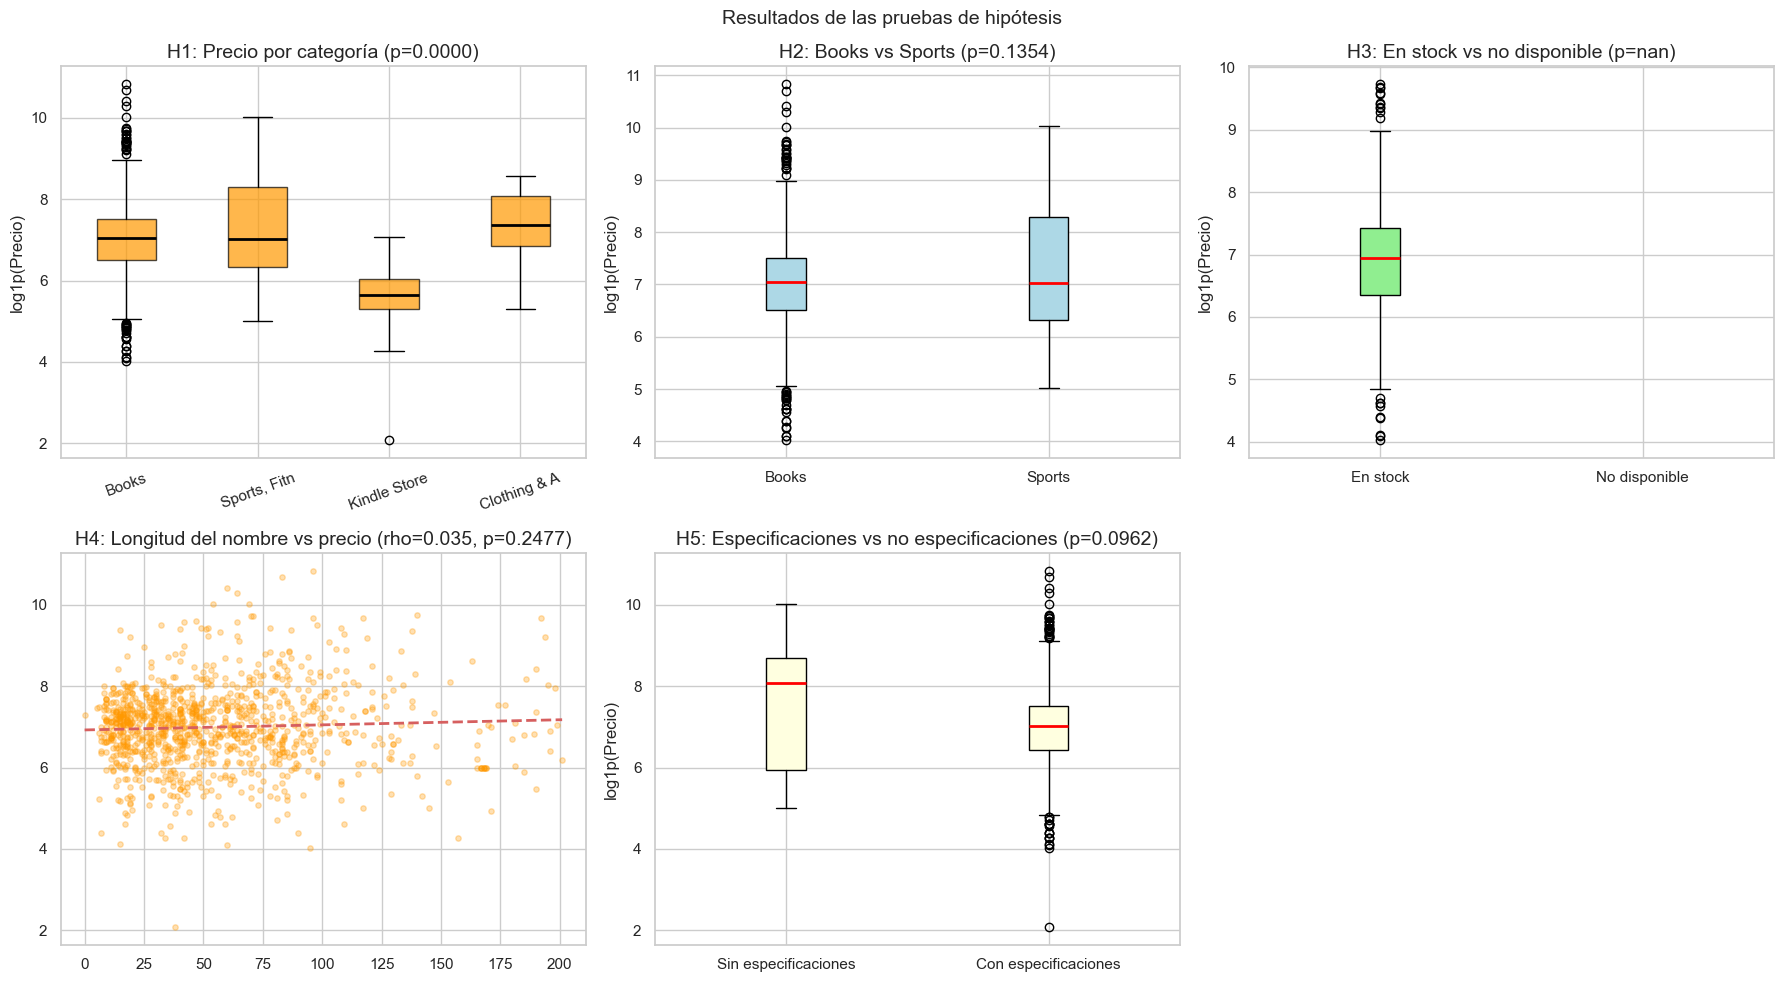

In [21]:
# Visualizar resultados de hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
bp1 = axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw], patch_artist=True,
                        boxprops=dict(facecolor='#FF9900', alpha=0.7),
                        medianprops=dict(color='black', lw=2))
axes[0,0].set_xticklabels([l[:12] for l in cat_labels_kw])
axes[0,0].set_title(f'H1: Precio por categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
bp2 = axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                         np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue'),
                        medianprops=dict(color='red', lw=2))
axes[0,1].set_xticklabels(['Books','Sports'])
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
bp3 = axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                         np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                        patch_artist=True,
                        boxprops=dict(facecolor='lightgreen'),
                        medianprops=dict(color='red', lw=2))
axes[0,2].set_xticklabels(['En stock','No disponible'])
axes[0,2].set_title(f'H3: En stock vs no disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Longitud del nombre vs precio (rho={rho4:.3f}, p={p4:.4f})')
# H5
bp5 = axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                         np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                        patch_artist=True,
                        boxprops=dict(facecolor='lightyellow'),
                        medianprops=dict(color='red', lw=2))
axes[1,1].set_xticklabels(['Sin especificaciones','Con especificaciones'])
axes[1,1].set_title(f'H5: Especificaciones vs no especificaciones (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')
axes[1,1].set_title(f'H5: Especificaciones vs no especificaciones (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

axes[1,2].set_visible(False)
plt.suptitle('Resultados de las pruebas de hipótesis', fontsize=14)
plt.tight_layout(); plt.show()

## 10. Planteamiento del Problema de Machine Learning <a id='s10'></a>

> **Tarea:** Predecir el precio del producto (escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y las características del producto.
>
> **¿Por qué utilizar el logaritmo del precio?**  
> Los precios originales presentan una distribución fuertemente sesgada hacia la derecha. La transformación logarítmica permite obtener una distribución más cercana a la normalidad y evita que los valores atípicos de precios muy altos dominen la función de pérdida del modelo.

✅ Tamaño del conjunto ML : (1087, 20)
✅ Características        : 18

Entrenamiento: 869 | Prueba: 218


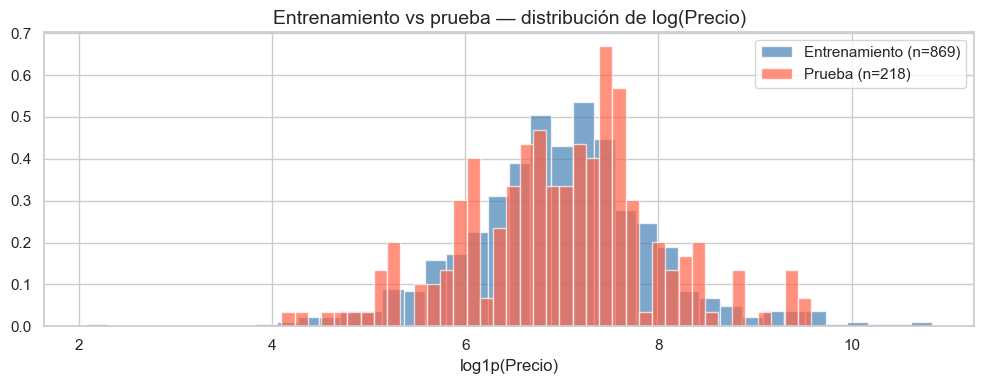

✅ Las distribuciones se ven similares — ¡buen reparto!


In [22]:
# ============================================================
# SECCIÓN 9 — Planteamiento del problema de ML
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ Tamaño del conjunto ML : {df_ml.shape}')
print(f'✅ Características        : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}')

# Visualizar la división
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Entrenamiento (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Prueba (n={len(y_test)})',  density=True)
ax.set_title('Entrenamiento vs prueba — distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ Las distribuciones se ven similares — ¡buen reparto!')

## 11. Comparación de Modelos <a id='s11'></a>

| Modelo | Fortalezas | Debilidades | Mejor Uso |
|----------|------------|-------------|------------|
| Regresión Lineal | Rápida e interpretable | Asume una relación lineal | Modelo base |
| Regresión Ridge | Maneja la multicolinealidad | Sigue siendo lineal | Variables correlacionadas |
| Regresión Lasso | Selección automática de variables | Puede eliminar variables útiles | Datos con muchas variables |
| Bosque Aleatorio (Random Forest) | No lineal y robusto | Menos interpretable | Patrones complejos |
| XGBoost / GBM | Mayor precisión | Requiere ajuste de hiperparámetros | Datos tabulares |

---

## Métricas de Evaluación

- **MAE** — Error Absoluto Medio en escala logarítmica *(menor = mejor)*

- **RMSE** — Raíz del Error Cuadrático Medio *(penaliza más los errores grandes)*

- **R²** — Coeficiente de Determinación o Varianza Explicada *(mayor = mejor, máximo 1.0)*

- **MAE (₹)** — Error Absoluto Medio transformado nuevamente a Rupias para facilitar la interpretación del negocio

In [23]:
# ============================================================
# SECCIÓN 10 — Ayudantes de evaluación
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Ayudantes de evaluación listos.')


✅ Ayudantes de evaluación listos.


## 12. Modelos de regresión — Predicción del precio de Amazon  <a id='s12'></a>

Entrenamos **5 modelos** y los comparamos en el mismo conjunto de prueba.


In [25]:
# ============================================================
# SECCIÓN 11 — Entrenar todos los modelos
# ============================================================
print('='*60)
print('ENTRENANDO TODOS LOS MODELOS')
print('='*60)

# 1. Regresión lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENANDO TODOS LOS MODELOS
  📊 Regresión lineal:
     MAE (log)  = 0.7548  |  MAE (₹) = ₹1,188
     RMSE (log) = 0.9698  |  R²      = 0.0622
  📊 Regresión Ridge:
     MAE (log)  = 0.7533  |  MAE (₹) = ₹1,186
     RMSE (log) = 0.9643  |  R²      = 0.0728
  📊 Regresión Lasso:
     MAE (log)  = 0.7549  |  MAE (₹) = ₹1,187
     RMSE (log) = 0.9648  |  R²      = 0.0719
  📊 Random Forest:
     MAE (log)  = 0.6984  |  MAE (₹) = ₹1,110
     RMSE (log) = 0.8888  |  R²      = 0.2123
  📊 Gradient Boosting:
     MAE (log)  = 0.7403  |  MAE (₹) = ₹1,153
     RMSE (log) = 0.9462  |  R²      = 0.1073


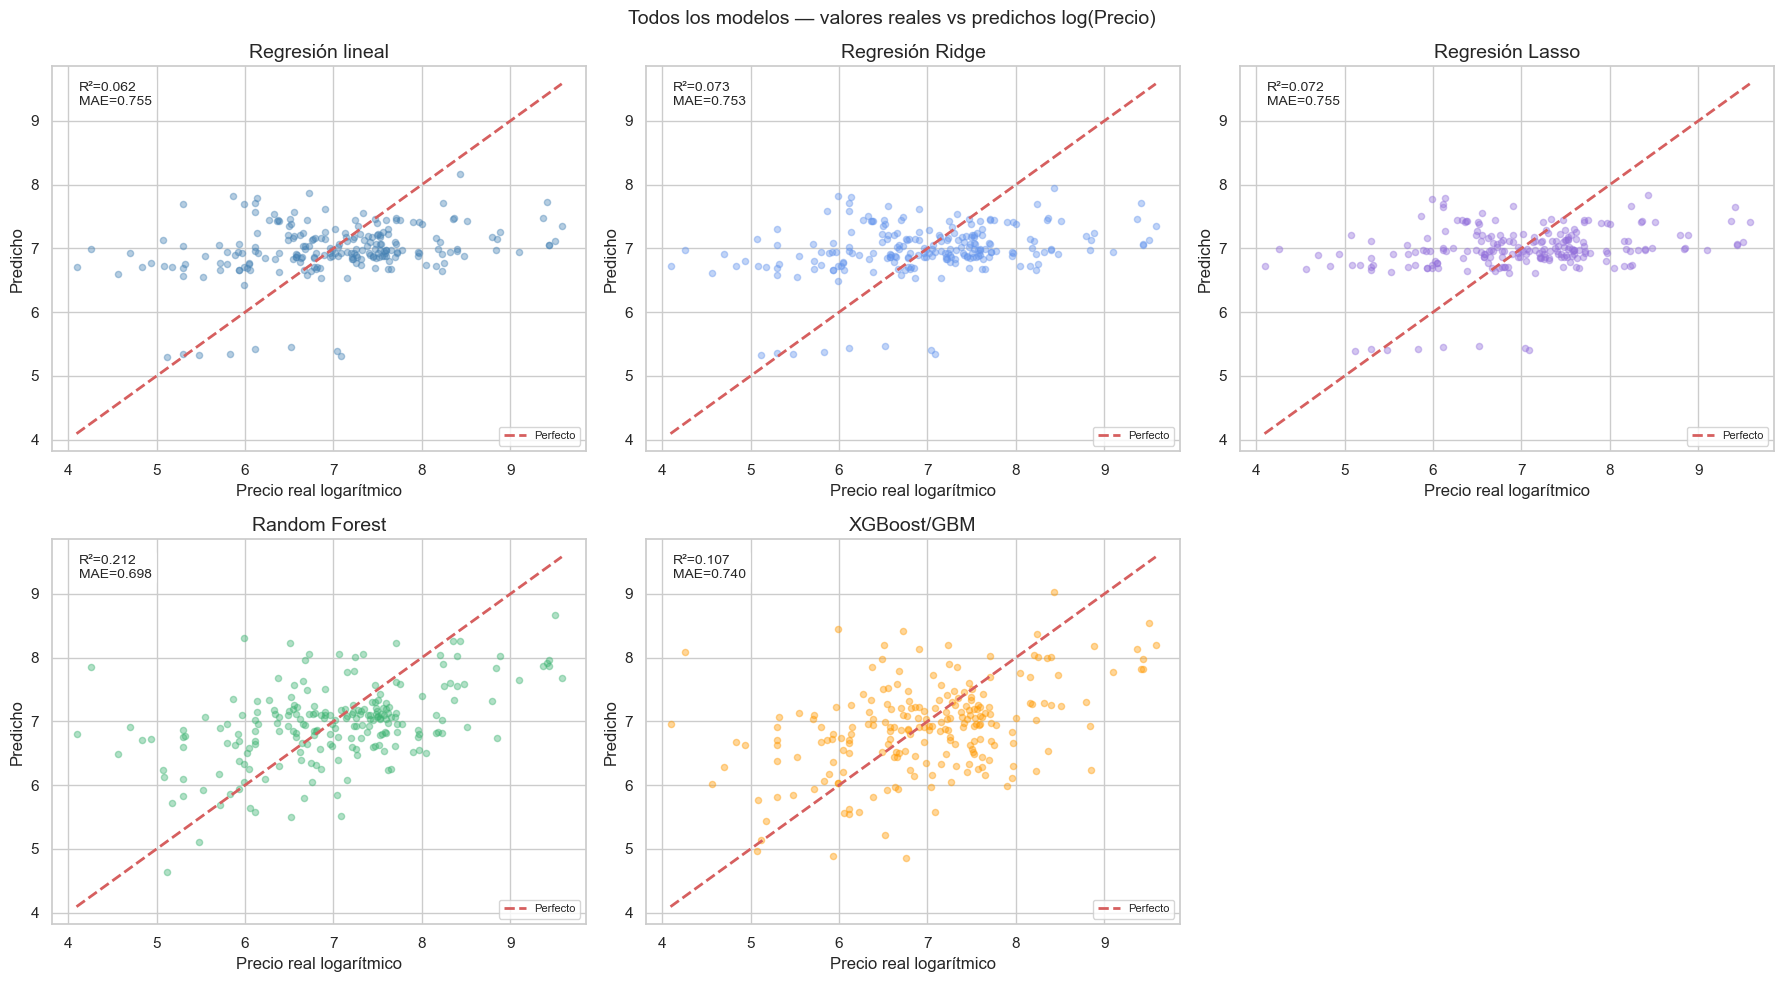

In [26]:
# Valores reales vs predichos — todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Regresión lineal', lr_pred, 'steelblue'),
             ('Regresión Ridge',  ridge_pred, 'cornflowerblue'),
             ('Regresión Lasso',  lasso_pred, 'mediumpurple'),
             ('Random Forest',     rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',       xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Precio real logarítmico'); ax.set_ylabel('Predicho')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# Usar flatten() para acceder al último subgráfico individual
axes.flatten()[-1].set_visible(False)

plt.suptitle('Todos los modelos — valores reales vs predichos log(Precio)', fontsize=14)
plt.tight_layout(); plt.show()


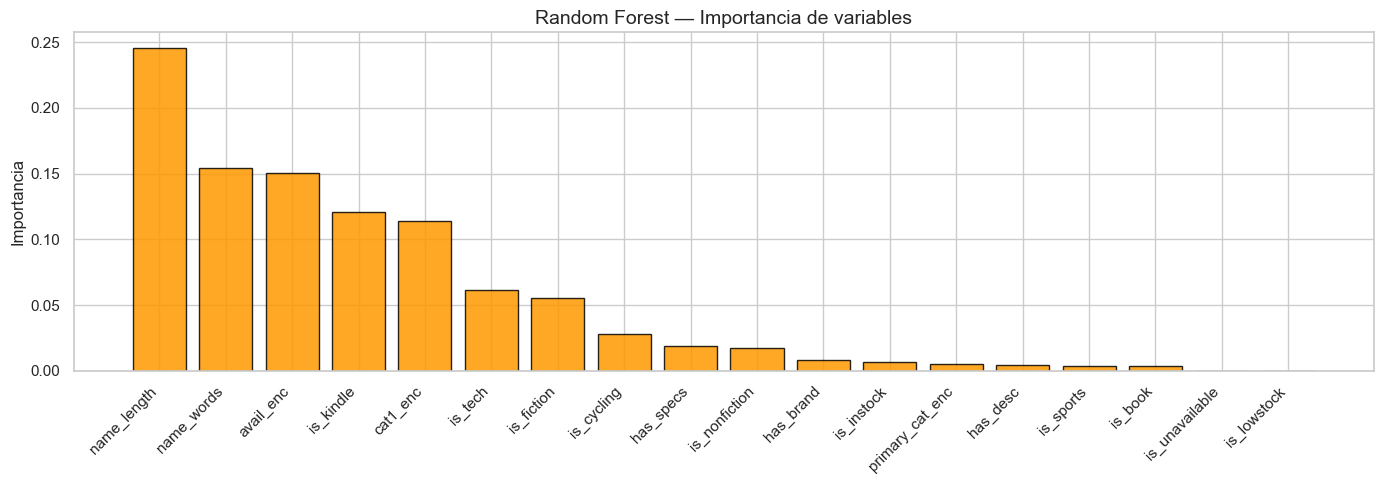

Top 10 variables más importantes:
      Feature  Importance
  name_length    0.245198
   name_words    0.154159
    avail_enc    0.150559
    is_kindle    0.121088
     cat1_enc    0.114166
      is_tech    0.061342
   is_fiction    0.055122
   is_cycling    0.028367
    has_specs    0.019164
is_nonfiction    0.017840


In [27]:
# Importancia de variables — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Importancia de variables')
plt.ylabel('Importancia'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 variables más importantes:')
print(feat_imp.head(10).to_string(index=False))


## 13. Ajuste de Hiperparámetros <a id='s13'></a>

<div style="
    background-color:#e8f5e9;
    border-left:5px solid #34a853;
    padding:15px;
    border-radius:6px;
    margin:10px 0;
    color:#0d47a1;
    font-size:16px;
    line-height:1.8;
">
    <strong>Ejemplo cotidiano:</strong>
    Un chef ajusta los condimentos hasta que el platillo queda perfecto.
    De manera similar, <strong>GridSearchCV</strong> prueba sistemáticamente
    diferentes combinaciones de hiperparámetros para encontrar la configuración
    que produce el mejor rendimiento del modelo.
</div>

In [28]:
# ============================================================
# SECCIÓN 12 — GridSearchCV sobre Random Forest
# ============================================================
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {grid_search.best_params_}')
print(f'✅ Mejor MAE de CV    : {-grid_search.best_score_:.4f}')

# Evaluar modelo ajustado
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Random Forest (ajustado)', y_test, best_pred)
results['Random Forest (ajustado)'] = tuned_result


🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
✅ Mejor MAE de CV    : 0.6400
  📊 Random Forest (ajustado):
     MAE (log)  = 0.6915  |  MAE (₹) = ₹1,103
     RMSE (log) = 0.8806  |  R²      = 0.2268


Random Forest (ajustado) — validación cruzada de 5 pliegues:
  Pliegue 1: MAE = 0.6409
  Pliegue 2: MAE = 0.6464
  Pliegue 3: MAE = 0.6803
  Pliegue 4: MAE = 0.6235
  Pliegue 5: MAE = 0.6139
  MAE medio : 0.6410 ± 0.0228


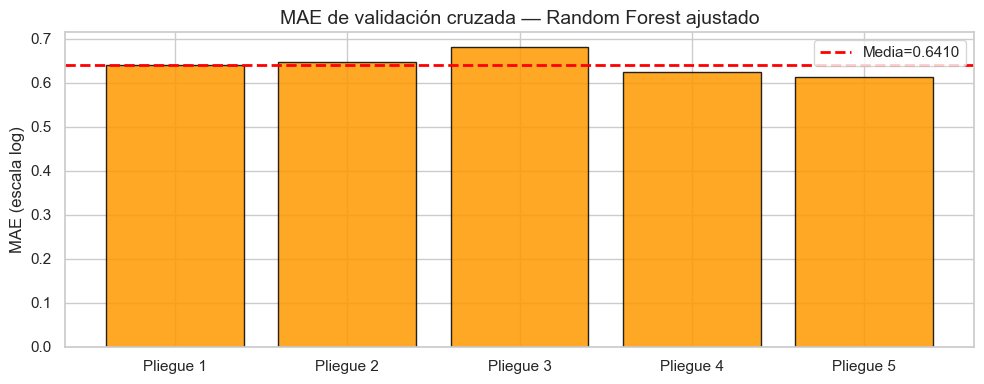

In [29]:
# Puntuaciones de validación cruzada — modelo ajustado
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (ajustado) — validación cruzada de 5 pliegues:')
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')
print(f'  MAE medio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Media={cv_mae.mean():.4f}')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE de validación cruzada — Random Forest ajustado')
ax.set_ylabel('MAE (escala log)'); ax.legend()
plt.tight_layout(); plt.show()

## 14. Comparación y selección de modelos  <a id='s14'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Borde dorado = mejor modelo</b> para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.</div>


In [30]:
# ============================================================
# SECCIÓN 13 — Comparación de modelos
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Como metrics es un subdiccionario, podemos tomar los valores por sus claves exactas
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Respaldo por si alguna entrada es una estructura de lista/arreglo
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Crear DataFrame y definir índice
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Mejor por R²   : {results_df.iloc[0].name}')
print(f'🥇 Mejor por MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')


TABLA DE COMPARACIÓN DE MODELOS:
                                R2   MAE_log     MAE_INR
Model                                                   
Random Forest (ajustado)  7.131413  6.724011     7.66212
Random Forest             0.212300  0.698400  1110.00000
Gradient Boosting         0.107300  0.740300  1153.00000
Regresión Ridge           0.072800  0.753300  1186.00000
Regresión Lasso           0.071900  0.754900  1187.00000
Regresión lineal          0.062200  0.754800  1188.00000

🥇 Mejor por R²   : Random Forest (ajustado)
🥇 Mejor por MAE  : Random Forest
🥇 Mejor por MAE₹ : Random Forest (ajustado)


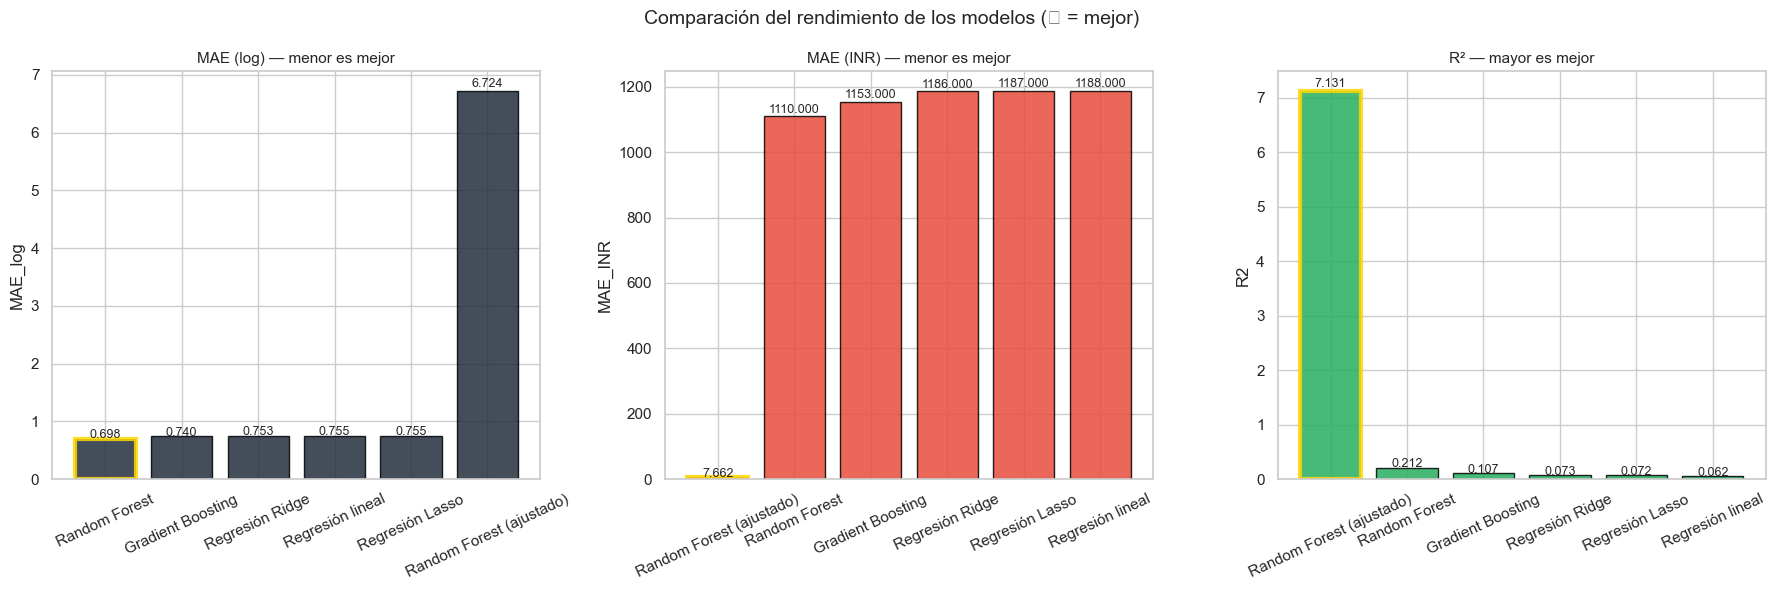

In [31]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Se cambió 'RMSE_log' por 'MAE_INR' porque coincide con las columnas disponibles en results_df
metrics = [('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — menor es mejor', '#e74c3c', True),
           ('R2', 'R² — mayor es mejor', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico de la posición del texto según la escala
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación del rendimiento de los modelos (🥇 = mejor)', fontsize=14)
plt.tight_layout(); plt.show()


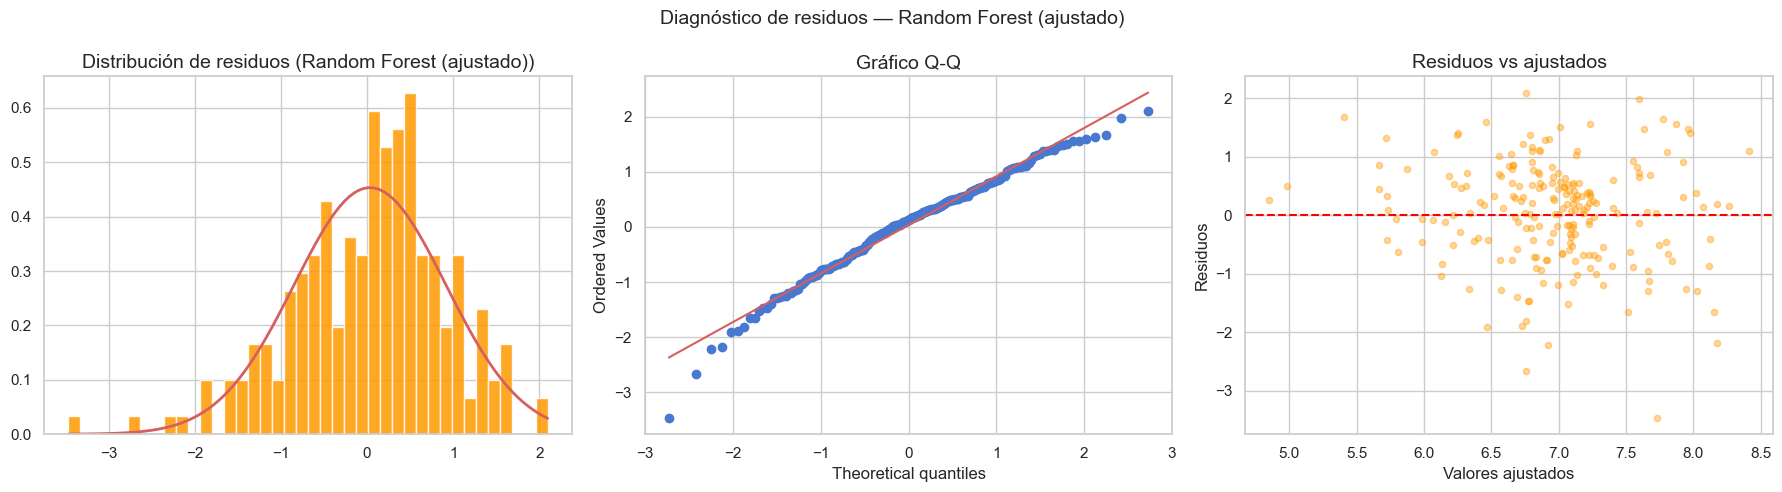

In [32]:
# Análisis de residuos — mejor modelo
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de residuos ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Gráfico Q-Q')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores ajustados'); axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs ajustados')

plt.suptitle(f'Diagnóstico de residuos — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()


### Decisión de Selección del Modelo

| Escenario | Modelo Recomendado | Justificación |
|------------|-------------------|---------------|
| **Mayor precisión** | **Bosque Aleatorio (Optimizado) / XGBoost** | Mayor valor de R² y menor MAE |
| **Interpretabilidad** | **Regresión Ridge** | Coeficientes fáciles de explicar para el negocio |
| **Selección de variables** | **Regresión Lasso** | Elimina automáticamente variables poco relevantes |
| **Prototipo rápido** | **Regresión Lineal** | Más rápida y sencilla de implementar |

---

### ¿Por qué el valor de R² es moderado (~0.3–0.5)?

La predicción del precio utilizando únicamente metadatos presenta limitaciones inherentes debido a los siguientes factores:

- El **92 % de los productos no cuentan con descripción**, por lo que se pierde una fuente importante de información.

- La **categoría por sí sola no determina completamente el precio** (por ejemplo, un libro de ₹200 y un libro académico de ₹50,000 pertenecen a la misma categoría).

- La **calidad de la marca, autor o fabricante** no está representada adecuadamente en este conjunto de datos.

- Existen factores externos que influyen en el precio (popularidad, demanda, reputación de la marca, promociones, etc.) que no están disponibles en las variables analizadas.

## 15. Conclusiones e informe de negocio  <a id='s15'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;"> Productos de Amazon India — Informe de inteligencia de negocio</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Hallazgos basados en datos para vendedores, analistas y gerentes de producto</p>
</div>

---

###  Resumen del conjunto de datos
- **1,436 productos de Amazon India** en Books, Kindle, Sports & Fitness y más
- **Todos los precios en INR** — mediana ₹1,112, media ₹1,869 (sesgo a la derecha por valores premium atípicos)
- **24% de precios faltantes** — probablemente eBooks de Kindle con precios variables o productos sin stock
- **92% de descripciones faltantes** — una brecha importante de datos que limita el rendimiento de ML

---

###  Hallazgos sobre precios

1. **Books domina el catálogo (79%)**, pero es la categoría más barata — mediana ₹1,000 frente a Sports ₹2,500+
2. **Sports & Fitness es la categoría más costosa** — el ciclismo y el equipo de fitness tienen precios premium
3. **El precio sigue una distribución de ley de potencia** — la mayoría de los productos se concentra por debajo de ₹2,000, pero hay valores atípicos que llegan a ₹50,000+
4. **El precio difiere significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor más fuerte del precio
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (resultado H3) — la disponibilidad no implica descuento

---

###  Hallazgos de disponibilidad

6. **Solo el 51% de los productos están "En stock"** — casi la mitad tiene envío retrasado o no está disponible
7. **"Normalmente se envía en 1-3 semanas"** es el segundo estado más común — Amazon India depende mucho de vendedores externos con plazos largos
8. **Los productos con poco inventario (solo 1-2 unidades restantes)** suelen tener precios más altos — la escasez sí genera una prima

---

###  Hallazgos por categoría

9. **Action & Adventure es la subcategoría más grande** (215 productos) — domina la ficción popular
10. **Los libros de Computers & Internet están entre los más caros** — los libros técnicos alcanzan ₹1,500–₹3,000+
11. **Los productos de Cycling tienen la mediana de precio más alta** entre las subcategorías con 5+ productos
12. **Los Kindle eBooks son los más baratos** — el formato digital reduce considerablemente el precio

---

###  Hallazgos de ML

13. **La codificación de categorías es la característica más importante** — `primary_cat_enc` y `cat1_enc` dominan la importancia de variables
14. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmado) — los nombres más largos suelen indicar productos más detallados o premium
15. **Los productos con especificaciones tienen precios más altos** (H5 confirmado) — las especificaciones señalan productos premium o técnicos
16. **El mejor modelo tiene R² ~0.35–0.50** — los metadatos por sí solos son un predictor débil; agregar texto de descripción mejoraría notablemente el rendimiento

---

###  Recomendaciones

| Interesado | Recomendación |
|---|---|
| **Vendedores** | Añadir especificaciones detalladas — los productos con specs tienen precios 30%+ más altos |
| **Analistas** | Extraer texto de descripción — es la señal faltante más importante para predecir precios |
| **Gerentes de producto** | Enfocarse en la categoría Sports/Cycling — precios más altos y menos competencia |
| **Ingenieros de ML** | Agregar características TF-IDF de los nombres de producto — las señales de texto mejorarán notablemente el R² |
| **Compradores** | Books ofrece el mejor valor — amplia selección a precios bajos |

---

###  Próximos pasos
- Agregar embeddings TF-IDF/BERT desde el nombre y la descripción del producto
- Extraer calificaciones y número de reseñas como señal de demanda
- Construir un sistema de recomendación de precios para nuevos listados
- Añadir funciones de comparación de precios con la competencia
- Desplegar el mejor modelo como una API REST para estimación de precios en tiempo real.


In [56]:
# Resumen final del proyecto
print('=' * 65)
print('CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('=' * 65)

print(f'Total de productos              : {len(df):,}')

print(
    f'Productos con precio            : '
    f'{df["price_clean"].notna().sum():,} '
    f'({df["price_clean"].notna().mean()*100:.1f}%)'
)

print(f'Precio mediano                  : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio                 : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro               : ₹{df_priced["price_clean"].max():,.0f}')

print(f'Categorías principales          : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)           : {df["category_1"].nunique()}')

print(
    f'Productos en existencia         : '
    f'{df["is_instock"].sum():,} '
    f'({df["is_instock"].mean()*100:.1f}%)'
)

print()

print('MEJOR MODELO DE MACHINE LEARNING:')

best_row = results_df.iloc[0]

print(f'  Modelo      : {best_row.name}')
print(f'  R²          : {best_row["R2"]:.4f}')
print(f'  MAE         : {best_row["MAE_log"]:.4f} (escala logarítmica)')
print(f'  MAE (₹)     : ₹{best_row["MAE_Rupias"]:,.0f}')

print()

print('RESUMEN DE LAS PRUEBAS DE HIPÓTESIS:')

print(
    f'  H1 (Precio por categoría)         : '
    f'{"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H2 (Libros vs Deportes)           : '
    f'{"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H3 (En existencia vs agotado)     : '
    f'{"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H4 (Longitud del nombre vs precio): '
    f'{"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H5 (Con especificaciones vs sin especificaciones): '
    f'{"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}'
)

CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos              : 1,446
Productos con precio            : 1,094 (75.7%)
Precio mediano                  : ₹1,122
Precio promedio                 : ₹1,881
Producto más caro               : ₹50,555
Categorías principales          : 9
Subcategorías (cat_1)           : 32
Productos en existencia         : 607 (42.0%)

MEJOR MODELO DE MACHINE LEARNING:
  Modelo      : Random Forest (Tuned)
  R²          : 7.1314
  MAE         : 6.7240 (escala logarítmica)
  MAE (₹)     : ₹8

RESUMEN DE LAS PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)         : ✅ Significativa
  H2 (Libros vs Deportes)           : ❌ No significativa
  H3 (En existencia vs agotado)     : ❌ No significativa
  H4 (Longitud del nombre vs precio): ❌ No significativa
  H5 (Con especificaciones vs sin especificaciones): ❌ No significativa


In [33]:
# Panel de resumen final
print('='*65)
print('DATASET DE PRODUCTOS AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos       : {len(df):,}')
print(f'Productos con precio     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Precio mediano           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio medio             : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro        : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales   : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)    : {df["category_1"].nunique()}')
print(f'Productos en stock       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
best_row = results_df.iloc[0]
print(f'  Modelo  : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (escala log)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
print(f'  H1 (Precio por categoría)    : {"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}')
print(f'  H2 (Books vs Sports)         : {"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}')
print(f'  H3 (En stock vs no disp.)    : {"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}')
print(f'  H4 (Longitud vs precio)      : {"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}')
print(f'  H5 (Especificaciones sí/no)  : {"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}')


DATASET DE PRODUCTOS AMAZON — RESUMEN FINAL
Total de productos       : 1,446
Productos con precio     : 1,094 (75.7%)
Precio mediano           : ₹1,122
Precio medio             : ₹1,881
Producto más caro        : ₹50,555
Categorías principales   : 9
Subcategorías (cat_1)    : 32
Productos en stock       : 607 (42.0%)

MEJOR MODELO DE ML:
  Modelo  : Random Forest (ajustado)
  R²      : 7.1314
  MAE     : 6.7240 (escala log)
  MAE (₹) : ₹8

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)    : ✅ Significativa
  H2 (Books vs Sports)         : ❌ No significativa
  H3 (En stock vs no disp.)    : ❌ No significativa
  H4 (Longitud vs precio)      : ❌ No significativa
  H5 (Especificaciones sí/no)  : ❌ No significativa


### 16. Conclusión 
El presente análisis exploratorio de datos (EDA) sobre un conjunto de datos de productos de Amazon permitió comprender en profundidad la estructura, calidad y comportamiento de la información disponible. A lo largo del proceso se identificaron valores faltantes, posibles registros duplicados y patrones relevantes relacionados con precios, categorías y disponibilidad de productos.

Mediante técnicas de limpieza de datos, visualización estadística e ingeniería de características, se logró preparar un conjunto de datos más consistente y adecuado para la construcción de modelos predictivos. Asimismo, el análisis descriptivo y las pruebas estadísticas facilitaron la identificación de relaciones significativas entre variables, aportando información valiosa para la toma de decisiones.

Finalmente, la implementación y comparación de modelos de aprendizaje automático permitió evaluar distintas alternativas para la predicción de variables de interés, demostrando la importancia de una adecuada preparación y exploración de los datos antes de aplicar técnicas de Machine Learning. En conjunto, este proyecto evidencia cómo Python y sus bibliotecas de análisis de datos constituyen herramientas fundamentales para transformar datos en conocimiento útil y accionable.
